<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Machine-Learning-repo/blob/main/Adaboost_algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [4]:
df=pd.DataFrame()

In [5]:
df['X1']=[1,2,3,4,5,6,7,8,8,9]
df['X2']=[6,4,3,2,5,7,8,5,3,4]
df['label']=[4,5,2,1,5,7,8,9,6,5]

In [6]:
df

,X1,X2,label
0,1,6,4
1,2,4,5
2,3,3,2
3,4,2,1
4,5,5,5
5,6,7,7
6,7,8,8
7,8,5,9
8,8,3,6
9,9,4,5


<Axes: xlabel='X1', ylabel='X2'>

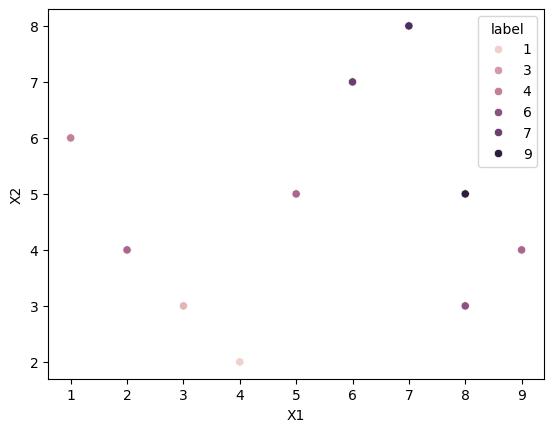

In [7]:
import seaborn as sns
sns.scatterplot(data=df, x='X1',y=df['X2'],hue=df['label'])

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt1=DecisionTreeClassifier(max_depth=1)

In [10]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [11]:
dt1.fit(X,y)      ## traiunig the 1st model

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 3.5\ngini = 0.84\nsamples = 10\nvalue = [1, 1, 1, 3, 1, 1, 1, 1]'),
 Text(0.25, 0.25, 'gini = 0.667\nsamples = 3\nvalue = [1, 1, 0, 0, 1, 0, 0, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.735\nsamples = 7\nvalue = [0, 0, 1, 3, 0, 1, 1, 1]'),
 Text(0.625, 0.5, '  False')]

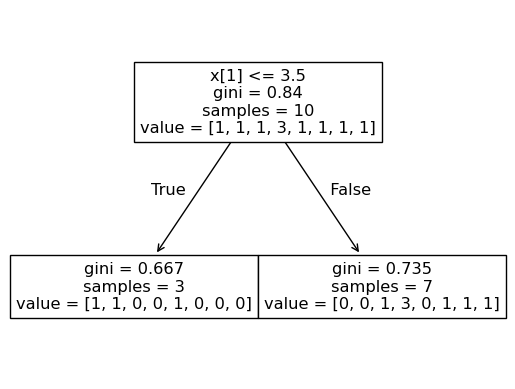

In [12]:
from sklearn.tree import plot_tree
plot_tree(dt1)

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

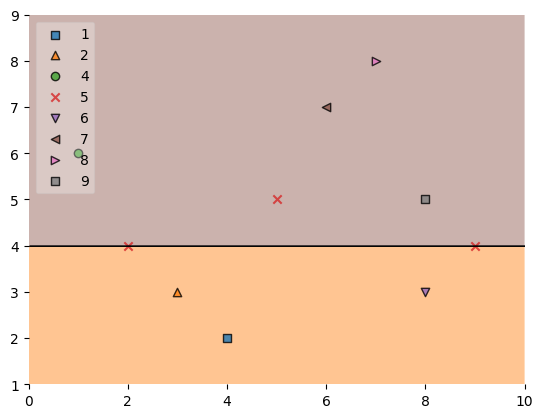

In [13]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [14]:
df['y_pred']=dt1.predict(X)

In [15]:
df

,X1,X2,label,y_pred
0,1,6,4,5
1,2,4,5,5
2,3,3,2,1
3,4,2,1,1
4,5,5,5,5
5,6,7,7,5
6,7,8,8,5
7,8,5,9,5
8,8,3,6,1
9,9,4,5,5


In [16]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

In [17]:
## calculate the model weight
alpha1=calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [19]:
def update_row_weights(row, alpha):
  if row['label']==row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

df['weights'] = 1/len(df)
df['weights'] = df.apply(lambda row: update_row_weights(row, alpha1), axis=1)

In [21]:
df['updated_weights']=df.apply(lambda row: update_row_weights(row, alpha1),axis=1)

In [22]:
df

,X1,X2,label,y_pred,weights,updated_weights
0,1,6,4,5,0.152753,0.233333
1,2,4,5,5,0.065465,0.042857
2,3,3,2,1,0.152753,0.233333
3,4,2,1,1,0.065465,0.042857
4,5,5,5,5,0.065465,0.042857
5,6,7,7,5,0.152753,0.233333
6,7,8,8,5,0.152753,0.233333
7,8,5,9,5,0.152753,0.233333
8,8,3,6,1,0.152753,0.233333
9,9,4,5,5,0.065465,0.042857


In [23]:
df['updated_weights'].sum()         ## sum should be be equal to 1

np.float64(1.5714285714285718)

In [25]:
df['normalized_weights']=df['updated_weights']/df['updated_weights'].sum()    ## noramlized updated weights as sum was exceeding more than 1
df

,X1,X2,label,y_pred,weights,updated_weights,normalized_weights
0,1,6,4,5,0.152753,0.233333,0.148485
1,2,4,5,5,0.065465,0.042857,0.027273
2,3,3,2,1,0.152753,0.233333,0.148485
3,4,2,1,1,0.065465,0.042857,0.027273
4,5,5,5,5,0.065465,0.042857,0.027273
5,6,7,7,5,0.152753,0.233333,0.148485
6,7,8,8,5,0.152753,0.233333,0.148485
7,8,5,9,5,0.152753,0.233333,0.148485
8,8,3,6,1,0.152753,0.233333,0.148485
9,9,4,5,5,0.065465,0.042857,0.027273
